## K_means

In [1]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
from sklearn.preprocessing import StandardScaler

### Base idade e salário

In [2]:
from sklearn.cluster import KMeans

In [3]:
x = [20, 27, 21, 37, 46, 53, 55, 47, 52, 32, 39, 41, 39, 48, 48] #idade
y = [1000, 1200, 2900, 1850, 900, 950, 2000, 2100, 3000, 5900, 4100, 5100, 7000, 5000, 6500] #salário

In [4]:
grafico = px.scatter(x = x, y = y)
grafico.show()

In [5]:
base_salario = np.array([[20, 1000], [27, 1200], [21, 2900], [37, 1850], [46, 900],
                         [53, 950], [55, 2000], [47, 2100], [52, 3000], [32, 5900],
                         [39, 4100], [41, 5100], [39, 7000], [48, 5000], [48, 6500]])
base_salario

array([[  20, 1000],
       [  27, 1200],
       [  21, 2900],
       [  37, 1850],
       [  46,  900],
       [  53,  950],
       [  55, 2000],
       [  47, 2100],
       [  52, 3000],
       [  32, 5900],
       [  39, 4100],
       [  41, 5100],
       [  39, 7000],
       [  48, 5000],
       [  48, 6500]])

In [6]:
scaler_salario = StandardScaler()
base_salario = scaler_salario.fit_transform(base_salario)
base_salario

array([[-1.87963884, -1.11413572],
       [-1.23255006, -1.01725435],
       [-1.78719758, -0.19376273],
       [-0.30813751, -0.70238991],
       [ 0.52383377, -1.1625764 ],
       [ 1.17092255, -1.13835606],
       [ 1.35580506, -0.62972888],
       [ 0.61627503, -0.5812882 ],
       [ 1.0784813 , -0.14532205],
       [-0.77034379,  1.25945777],
       [-0.12325501,  0.38752547],
       [ 0.0616275 ,  0.8719323 ],
       [-0.12325501,  1.79230528],
       [ 0.70871628,  0.82349162],
       [ 0.70871628,  1.55010187]])

In [7]:
kmeans_salario = KMeans(n_clusters = 3)
kmeans_salario.fit(base_salario)

c:\Users\olive\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



KMeans(n_clusters=3)

In [8]:
centroides_salario = kmeans_salario.cluster_centers_
centroides_salario

array([[ 0.07703438,  1.11413572],
       [-1.301881  , -0.75688568],
       [ 0.94906354, -0.73145432]])

In [9]:
scaler_salario.inverse_transform(kmeans_salario.cluster_centers_)

array([[  41.16666667, 5600.        ],
       [  26.25      , 1737.5       ],
       [  50.6       , 1790.        ]])

In [10]:
rotulos = kmeans_salario.labels_
rotulos

array([1, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0], dtype=int32)

In [11]:
grafico1 = px.scatter(x = base_salario[:, 0], y = base_salario[:, 1], color = rotulos)
grafico2 = px.scatter(x = centroides_salario[:, 0], y = centroides_salario[:, 1], size = [12, 12, 12])
grafico3 = go.Figure(data = grafico1.data + grafico2.data)
grafico3.show()

### Dados randômicos

In [12]:
from sklearn.datasets import make_blobs

In [13]:
x_random, y_random = make_blobs(n_samples = 200, centers = 5)
x_random, y_random

(array([[-10.09502432,   4.11157246],
        [ -8.15142908,   5.0602157 ],
        [ -6.6397825 ,  -1.76293831],
        [ -6.74323731, -10.23114245],
        [ -4.98638126,   0.05510706],
        [ -6.03059014,  -1.29469886],
        [ -6.02147806,  -0.28768028],
        [ -8.20375785,   3.92093108],
        [ -6.89691488,  -6.42051986],
        [ -9.00776523,  -9.121001  ],
        [ -4.65807752,  -4.2729992 ],
        [ -7.58731455,  -2.67024256],
        [ -3.99666545,  -4.7524786 ],
        [ -9.57616345,   4.4621852 ],
        [ -7.24413178,  -0.44449568],
        [ -5.27524462,  -4.45436258],
        [ -4.75532328,  -3.19044153],
        [ -4.54871603,  -2.85237611],
        [ -4.88830372,  -4.95192653],
        [ -4.48758741,  -0.66026147],
        [ -9.24960154,   5.45974749],
        [ -5.66638542,  -2.31032421],
        [ -8.93112359,   4.1814417 ],
        [ -5.58321086,  -1.41771124],
        [ -7.39056047,  -2.54400701],
        [ -9.87898907,   4.61080856],
        [ -3

In [14]:
grafico = px.scatter(x =x_random[:, 0], y = x_random[:, 1])
grafico.show()

In [15]:
kmeans_blobs = KMeans(n_clusters = 5)
kmeans_blobs.fit(x_random)

c:\Users\olive\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



KMeans(n_clusters=5)

In [16]:
rotulos = kmeans_blobs.predict(x_random)
rotulos

array([3, 3, 1, 2, 1, 1, 1, 3, 2, 2, 4, 0, 4, 3, 1, 4, 4, 4, 4, 1, 3, 4,
       3, 1, 0, 3, 1, 0, 4, 1, 0, 1, 4, 4, 4, 2, 3, 4, 3, 4, 0, 4, 2, 4,
       0, 0, 3, 1, 2, 1, 1, 4, 3, 4, 0, 1, 2, 2, 2, 4, 0, 4, 3, 2, 4, 1,
       0, 3, 2, 2, 2, 2, 0, 0, 3, 1, 2, 3, 4, 2, 3, 2, 0, 3, 2, 3, 1, 0,
       4, 2, 4, 0, 2, 4, 1, 2, 2, 4, 0, 4, 3, 3, 4, 4, 4, 2, 1, 4, 3, 0,
       4, 0, 1, 0, 4, 1, 2, 1, 3, 0, 1, 1, 4, 0, 0, 1, 1, 4, 4, 2, 0, 1,
       4, 3, 1, 1, 0, 3, 0, 0, 2, 3, 3, 1, 2, 0, 2, 4, 2, 0, 3, 4, 2, 2,
       3, 2, 2, 2, 3, 0, 3, 3, 1, 4, 3, 1, 2, 2, 1, 4, 1, 4, 0, 4, 0, 2,
       2, 3, 3, 0, 2, 3, 3, 3, 0, 2, 3, 1, 3, 0, 3, 4, 1, 1, 4, 1, 4, 1,
       4, 2], dtype=int32)

In [17]:
centroides = kmeans_blobs.cluster_centers_
centroides

array([[-8.70165383, -3.37754105],
       [-5.32587533, -0.4306485 ],
       [-8.84238019, -8.62292899],
       [-9.76683242,  4.61045654],
       [-4.95776347, -3.50630297]])

In [18]:
grafico1 = px.scatter(x = x_random[:, 0], y = x_random[:, 1], color = rotulos)
grafico2 = px.scatter(x = centroides[:, 0], y = centroides[:, 1], size = [5, 5, 5, 5, 5])
grafico3 = go.Figure(data = grafico1.data + grafico2.data)
grafico3.show()

### Base de dados cartão de crédito - 1 atributo

In [19]:
import pandas as pd
base_cartao = pd.read_csv('credit_card_clients.csv', header=1)
base_cartao

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [20]:
base_cartao['BILL_TOTAL'] = base_cartao['BILL_AMT1'] + base_cartao['BILL_AMT2'] + base_cartao['BILL_AMT3'] + base_cartao['BILL_AMT4'] + base_cartao['BILL_AMT5'] + base_cartao['BILL_AMT6']


In [21]:
base_cartao

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,BILL_TOTAL
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,689,0,0,0,0,1,7704
1,2,120000,2,2,2,26,-1,2,0,0,...,3455,3261,0,1000,1000,1000,0,2000,1,17077
2,3,90000,2,2,2,34,0,0,0,0,...,14948,15549,1518,1500,1000,1000,1000,5000,0,101653
3,4,50000,2,2,1,37,0,0,0,0,...,28959,29547,2000,2019,1200,1100,1069,1000,0,231334
4,5,50000,1,2,1,57,-1,0,-1,0,...,19146,19131,2000,36681,10000,9000,689,679,0,109339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,31237,15980,8500,20000,5003,3047,5000,1000,0,725349
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,5190,0,1837,3526,8998,129,0,0,0,21182
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20582,19357,0,0,22000,4200,2000,3100,1,70496
29998,29999,80000,1,3,1,41,1,-1,0,0,...,11855,48944,85900,3409,1178,1926,52964,1804,1,266611


In [22]:
x_cartao = base_cartao.iloc[:, [1, 25]].values
x_cartao

array([[ 20000,   7704],
       [120000,  17077],
       [ 90000, 101653],
       ...,
       [ 30000,  70496],
       [ 80000, 266611],
       [ 50000, 230874]])

In [23]:
scaler_cartao = StandardScaler()
x_cartao = scaler_cartao.fit_transform(x_cartao)
x_cartao

array([[-1.13672015, -0.69069198],
       [-0.3659805 , -0.66599747],
       [-0.59720239, -0.44316987],
       ...,
       [-1.05964618, -0.52525745],
       [-0.67427636, -0.00856436],
       [-0.90549825, -0.10271861]])

In [24]:
wcss = []
for i in range(1, 11):
    kmeans_cartao = KMeans(n_clusters = i, random_state=0)
    kmeans_cartao.fit(x_cartao)
    wcss.append(kmeans_cartao.inertia_)


In [25]:
wcss

[59999.99999999988,
 35197.834391257304,
 20128.20263562338,
 15892.249716910732,
 10708.603774943513,
 8604.404544864527,
 7684.904846136835,
 6593.001391781401,
 5669.721586002743,
 5055.083531903292]

In [26]:
grafico = px.line(x = range(1, 11), y = wcss)
grafico.show()

In [27]:
kmeans_cartao = KMeans(n_clusters = 4, random_state=0)
rotulos = kmeans_cartao.fit_predict(x_cartao)


In [28]:
grafico = px.scatter(x = x_cartao[:, 0], y = x_cartao[:, 1], color = rotulos)
grafico.show()

In [29]:
lista_clientes = np.column_stack((base_cartao, rotulos))
lista_clientes

array([[     1,  20000,      2, ...,      1,   7704,      0],
       [     2, 120000,      2, ...,      1,  17077,      0],
       [     3,  90000,      2, ...,      0, 101653,      0],
       ...,
       [ 29998,  30000,      1, ...,      1,  70496,      0],
       [ 29999,  80000,      1, ...,      1, 266611,      0],
       [ 30000,  50000,      1, ...,      1, 230874,      0]])

### Base de cados cartão de crédito - mais atributos

In [30]:
base_cartao.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month', 'BILL_TOTAL'],
      dtype='object')

In [31]:
x_cartao_mais = base_cartao.iloc[:, [1, 2, 3, 4, 5, 25]].values
x_cartao_mais

array([[ 20000,      2,      2,      1,     24,   7704],
       [120000,      2,      2,      2,     26,  17077],
       [ 90000,      2,      2,      2,     34, 101653],
       ...,
       [ 30000,      1,      2,      2,     37,  70496],
       [ 80000,      1,      3,      1,     41, 266611],
       [ 50000,      1,      2,      1,     46, 230874]])

In [32]:
scaler_cartao_mais = StandardScaler()
x_cartao_mais = scaler_cartao_mais.fit_transform(x_cartao_mais)
x_cartao_mais

array([[-1.13672015,  0.81016074,  0.18582826, -1.05729503, -1.24601985,
        -0.69069198],
       [-0.3659805 ,  0.81016074,  0.18582826,  0.85855728, -1.02904717,
        -0.66599747],
       [-0.59720239,  0.81016074,  0.18582826,  0.85855728, -0.16115646,
        -0.44316987],
       ...,
       [-1.05964618, -1.23432296,  0.18582826,  0.85855728,  0.16430256,
        -0.52525745],
       [-0.67427636, -1.23432296,  1.45111372, -1.05729503,  0.59824792,
        -0.00856436],
       [-0.90549825, -1.23432296,  0.18582826, -1.05729503,  1.14067961,
        -0.10271861]])

In [33]:
wcss = []
for i in range(1, 11):
    kmeans_cartao_mais = KMeans(n_clusters = i)
    kmeans_cartao_mais.fit(x_cartao_mais)
    wcss.append(kmeans_cartao_mais.inertia_)

In [34]:
grafico = px.line(x = range(1, 11), y = wcss)
grafico.show()

In [35]:
kmeans_cartao_mais = KMeans(n_clusters = 4, random_state=0)
rotulos = kmeans_cartao_mais.fit_predict(x_cartao_mais)

In [36]:
rotulos

array([0, 1, 1, ..., 3, 0, 0], dtype=int32)

In [37]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_cartao_mais_pca = pca.fit_transform(x_cartao_mais)

In [38]:
x_cartao_mais_pca.shape

(30000, 2)

In [39]:
x_cartao_mais_pca

array([[-0.74082054, -1.13671858],
       [-1.48027121, -0.30100547],
       [-0.94737386, -0.48666789],
       ...,
       [-0.79468657, -0.90012663],
       [ 1.17562376, -1.54746987],
       [ 1.13614987, -1.14039836]])

In [40]:
grafico = px.scatter(x = x_cartao_mais_pca[:, 0], y = x_cartao_mais_pca[:, 1], color = rotulos)
grafico.show()

In [41]:
lista_clientes = np.column_stack((base_cartao, rotulos))
lista_clientes

array([[     1,  20000,      2, ...,      1,   7704,      0],
       [     2, 120000,      2, ...,      1,  17077,      1],
       [     3,  90000,      2, ...,      0, 101653,      1],
       ...,
       [ 29998,  30000,      1, ...,      1,  70496,      3],
       [ 29999,  80000,      1, ...,      1, 266611,      0],
       [ 30000,  50000,      1, ...,      1, 230874,      0]])

## Agrupamento Hierárquico

In [42]:
base_salario

array([[-1.87963884, -1.11413572],
       [-1.23255006, -1.01725435],
       [-1.78719758, -0.19376273],
       [-0.30813751, -0.70238991],
       [ 0.52383377, -1.1625764 ],
       [ 1.17092255, -1.13835606],
       [ 1.35580506, -0.62972888],
       [ 0.61627503, -0.5812882 ],
       [ 1.0784813 , -0.14532205],
       [-0.77034379,  1.25945777],
       [-0.12325501,  0.38752547],
       [ 0.0616275 ,  0.8719323 ],
       [-0.12325501,  1.79230528],
       [ 0.70871628,  0.82349162],
       [ 0.70871628,  1.55010187]])

In [43]:
grafico = px.scatter(x = base_salario[:, 0], y = base_salario[:, 1])
grafico.show()

In [44]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

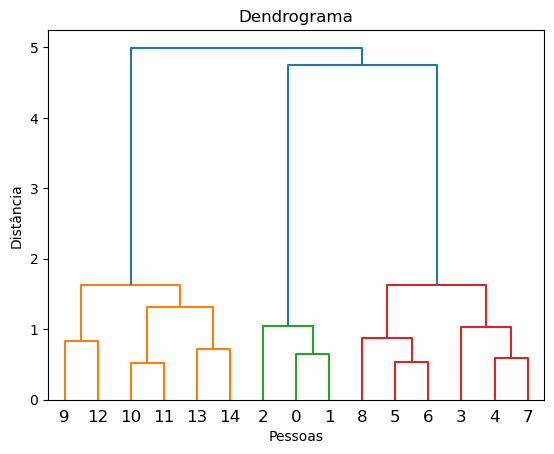

In [45]:
dendrograma = dendrogram(linkage(base_salario, method = 'ward'))
plt.title('Dendrograma')
plt.xlabel('Pessoas')
plt.ylabel('Distância');

In [46]:
from sklearn.cluster import AgglomerativeClustering

In [47]:
hc_salario = AgglomerativeClustering(n_clusters=3, linkage='ward')
rotulos = hc_salario.fit_predict(base_salario)
rotulos

array([2, 2, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0])

In [48]:
grafico = px.scatter(x = base_salario[:, 0], y = base_salario[:, 1], color = rotulos)
grafico.show()

### Base Cartão de crédito

In [50]:
x_cartao

array([[-1.13672015, -0.69069198],
       [-0.3659805 , -0.66599747],
       [-0.59720239, -0.44316987],
       ...,
       [-1.05964618, -0.52525745],
       [-0.67427636, -0.00856436],
       [-0.90549825, -0.10271861]])

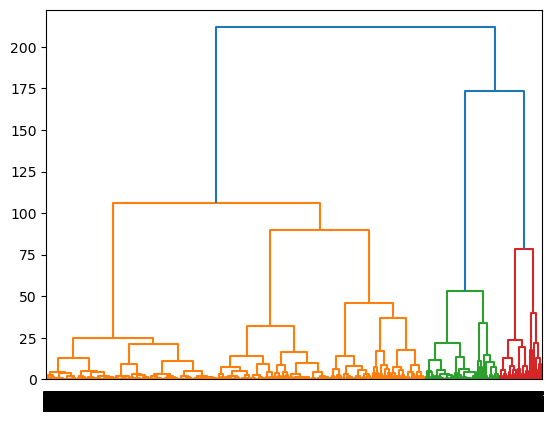

In [51]:
dendrograma = dendrogram(linkage(x_cartao, method = 'ward'))

In [53]:
hc_cartao = AgglomerativeClustering(n_clusters=3, linkage='ward')
rotulos = hc_cartao.fit_predict(x_cartao)
rotulos

array([0, 0, 0, ..., 0, 0, 0])

In [54]:
grafico = px.scatter(x = x_cartao[:, 0], y = x_cartao[:, 1], color = rotulos)
grafico.show()

## DBSCAN

### Base salário idade

In [55]:
base_salario

array([[-1.87963884, -1.11413572],
       [-1.23255006, -1.01725435],
       [-1.78719758, -0.19376273],
       [-0.30813751, -0.70238991],
       [ 0.52383377, -1.1625764 ],
       [ 1.17092255, -1.13835606],
       [ 1.35580506, -0.62972888],
       [ 0.61627503, -0.5812882 ],
       [ 1.0784813 , -0.14532205],
       [-0.77034379,  1.25945777],
       [-0.12325501,  0.38752547],
       [ 0.0616275 ,  0.8719323 ],
       [-0.12325501,  1.79230528],
       [ 0.70871628,  0.82349162],
       [ 0.70871628,  1.55010187]])

In [56]:
from sklearn.cluster import DBSCAN

In [59]:
dbscan_salario = DBSCAN(eps=0.95, min_samples=2)
dbscan_salario.fit(base_salario)

DBSCAN(eps=0.95, min_samples=2)

In [60]:
rotulos = dbscan_salario.labels_
rotulos

array([0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2])

In [61]:
grafico = px.scatter(x = base_salario[:, 0], y = base_salario[:, 1], color = rotulos)
grafico.show()

### Base cartão de crédito

In [62]:
x_cartao

array([[-1.13672015, -0.69069198],
       [-0.3659805 , -0.66599747],
       [-0.59720239, -0.44316987],
       ...,
       [-1.05964618, -0.52525745],
       [-0.67427636, -0.00856436],
       [-0.90549825, -0.10271861]])

In [82]:
dbscan_artao = DBSCAN(eps=0.37, min_samples=5)
rotulos = dbscan_artao.fit_predict(x_cartao)

In [83]:
rotulos

array([0, 0, 0, ..., 0, 0, 0])

In [84]:
np.unique(rotulos, return_counts=True)

(array([-1,  0,  1,  2]), array([   52, 29920,    18,    10]))

In [85]:
grafico = px.scatter(x = x_cartao[:, 0], y = x_cartao[:, 1], color = rotulos)
grafico.show()

### K_means x Hierárquico x DBSCAN

In [86]:
from sklearn import datasets

In [92]:
x_random, y_random = datasets.make_moons(n_samples=1500, noise = 0.09)

In [93]:
x_random

array([[ 0.80635931,  0.70708631],
       [-0.35312774,  1.08335739],
       [-0.15837896,  1.05129611],
       ...,
       [-0.54137492,  0.72475717],
       [-0.05595531,  0.45354356],
       [ 2.00344979,  0.12501794]])

In [94]:
y_random

array([0, 0, 0, ..., 0, 1, 1])

In [95]:
np.unique(y_random)

array([0, 1])

In [96]:
grafico = px.scatter(x = x_random[:,0], y = x_random[:,1])
grafico.show()

In [97]:
kmeans = KMeans(n_clusters=2)
rotulos = kmeans.fit_predict(x_random)
grafico = px.scatter(x = x_random[:, 0], y = x_random[:, 1], color = rotulos)
grafico.show()

In [98]:
hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
rotulos = hc.fit_predict(x_random)

In [100]:
dbscan = DBSCAN(eps = 0.1)
rotulos = dbscan.fit_predict(x_random)
grafico = px.scatter(x = x_random[:, 0], y = x_random[:, 1], color = rotulos)
grafico.show()